In [13]:
import os
import numpy as np
import pandas as pd

from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader

import torchvision.transforms as transforms
from torchvision.utils import make_grid

import matplotlib.pyplot as plt

In [ ]:
class FoodX251Dataset(Dataset):
    """Custom Dataset class to parse and serve FoodX-251 images and labels."""
    def __init__(self, image_dir, label_file, transform=None):
        self.image_dir = image_dir
        self.transform = transform
        
        # Load the CSV or TXT file linking image names to class IDs
        assert label_file.endswith('.csv')
        self.df = pd.read_csv(label_file, names=['image_name', 'label_id'], header=0)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = self.df.iloc[idx, 0]
        img_path = os.path.join(self.image_dir, img_name)
        
        try:
            image = Image.open(img_path).convert('RGB')
        except (IOError, SyntaxError) as e:
            print(f"Warning: Skipping corrupted image {img_name}")
            return self.__getitem__(0)
            
        if self.transform:
            image = self.transform(image)

        label = torch.tensor(self.df.iloc[idx, 1], dtype=torch.long)

        return image, label

In [3]:
def get_data_loaders(data_dir, train_labels, val_labels, batch_size=64, img_size=224):
    """Generates optimized PyTorch DataLoaders for Training and Validation workflows."""
    
    # Normalization values derived from ImageNet
    mean_stats = [0.485, 0.456, 0.406]
    std_stats = [0.229, 0.224, 0.225]
    
    # Training Transforms: Add basic geometric invariance
    train_transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.ToTensor(),
        transforms.Normalize(mean=mean_stats, std=std_stats)
    ])
    
    # Validation Transforms: No augmentations, just strict formatting
    val_transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=mean_stats, std=std_stats)
    ])
    
    train_dataset = FoodX251Dataset(
        image_dir=os.path.join(data_dir, 'train_set'),
        label_file=train_labels,
        transform=train_transform
    )
    
    val_dataset = FoodX251Dataset(
        image_dir=os.path.join(data_dir, 'val_set'),
        label_file=val_labels,
        transform=val_transform
    )
    
    train_loader = DataLoader(
        train_dataset, 
        batch_size=batch_size, 
        shuffle=True, 
        num_workers=8, 
        pin_memory=True,
        drop_last=True
    )
    
    val_loader = DataLoader(
        val_dataset, 
        batch_size=batch_size, 
        shuffle=False, 
        num_workers=8, 
        pin_memory=True
    )
    
    return train_loader, val_loader

In [10]:
DATA_DIR = "./data"
META_DATA_DIR = "./data/meta/"

img_size = 224
batch_size = 32

try:
    train_loader, val_loader = get_data_loaders(
        data_dir=DATA_DIR,
        train_labels=META_DATA_DIR + "train_labels.csv",
        val_labels=META_DATA_DIR + "val_labels.csv",
        batch_size=batch_size,
        img_size=img_size
    )

    classes = np.loadtxt(META_DATA_DIR + "class_list.txt", dtype=str, usecols=1)
    
    images, labels = next(iter(train_loader))
    
    print("\n--- Pipeline Verification Metrics ---")
    print(f"Successfully loaded a batch of size: {images.shape[0]}")
    print(f"Tensor shape (Batch, Channels, Height, Width): {images.shape}")
    print(f"Target Labels shape: {labels.shape}")
    print(f"Value range - Min: {images.min():.2f} | Max: {images.max():.2f}")
    print("Pipeline Status: Functional and verified ✅")
    
except FileNotFoundError as e:
    print(f"\nConfiguration Error: Verify file paths. Details: {e}")


--- Pipeline Verification Metrics ---
Successfully loaded a batch of size: 32
Tensor shape (Batch, Channels, Height, Width): torch.Size([32, 3, 224, 224])
Target Labels shape: torch.Size([32])
Value range - Min: -2.12 | Max: 2.64
Pipeline Status: Functional and verified ✅


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.82].


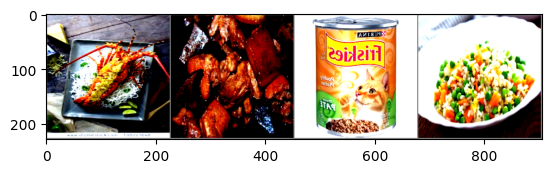

In [37]:
def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()


# get some random training images
images, labels = next(iter(train_loader))

# show images
imshow(make_grid(images[:4]))

In [5]:
import numpy as np
from sklearn.decomposition import PCA

def run_pca_on_loader(data_loader, n_components=2, n_images=3000, target_classes=None):
    """
    Extracts a subset of images from the loader, flattens them, 
    and applies PCA to project them into 2D space.
    """
    collected_images = []
    collected_labels = []
    images_processed = 0
    
    print("Extracting and flattening image tensors...")
    
    # Deactivate gradient calculations for speed
    with torch.no_grad():
        for imgs, lbls in data_loader:
            batch_size = imgs.size(0)
            flattened_imgs = imgs.view(batch_size, -1).cpu().numpy()
            lbls_np = lbls.cpu().numpy()
            
            for i in range(batch_size):
                current_label = lbls_np[i]
                
                if target_classes is not None and current_label not in target_classes:
                    continue
                    
                collected_images.append(flattened_imgs[i])
                collected_labels.append(current_label)
                images_processed += 1
                
                if images_processed >= n_images:
                    break
            
            if images_processed >= n_images:
                break
                
    X = np.array(collected_images)
    y = np.array(collected_labels)
    print(f"Data ready for PCA. Matrix shape: {X.shape}")
    
    print("Computing PCA components (this may take a minute)...")
    pca = PCA(n_components=n_components)
    X_pca = pca.fit_transform(X)
    
    explained_variance = pca.explained_variance_ratio_ * 100
    print(f"Variance explained: PC1 = {explained_variance[0]:.2f}%, PC2 = {explained_variance[1]:.2f}%")
    
    return X_pca, y, target_classes

In [ ]:
# Run the extraction
# Let's pick 5 random class IDs to make the visualization clean
selected_classes = [0, 10, 50, 100, 150] 

X_pca, y_labels, classes_used = run_pca_on_loader(
    train_loader, 
    n_components=4,
    n_images=100, 
    target_classes=selected_classes
)

Extracting and flattening image tensors...
Data ready for PCA. Matrix shape: (100, 150528)
Computing PCA components (this may take a minute)...
